Categorical: ['Sex', 'Embarked', 'who', 'embark_town', 'alive']
Numerical: ['Pclass', 'age', 'sibsp', 'parch', 'Fare']
OneHot shape: (891, 4)
StandardScaler -> mean: 0.00, std: 1.00, min: -0.65, max: 9.67
MinMaxScaler -> mean: 0.06, std: 0.10, min: 0.00, max: 1.00
RobustScaler -> mean: 0.77, std: 2.15, min: -0.63, max: 21.56


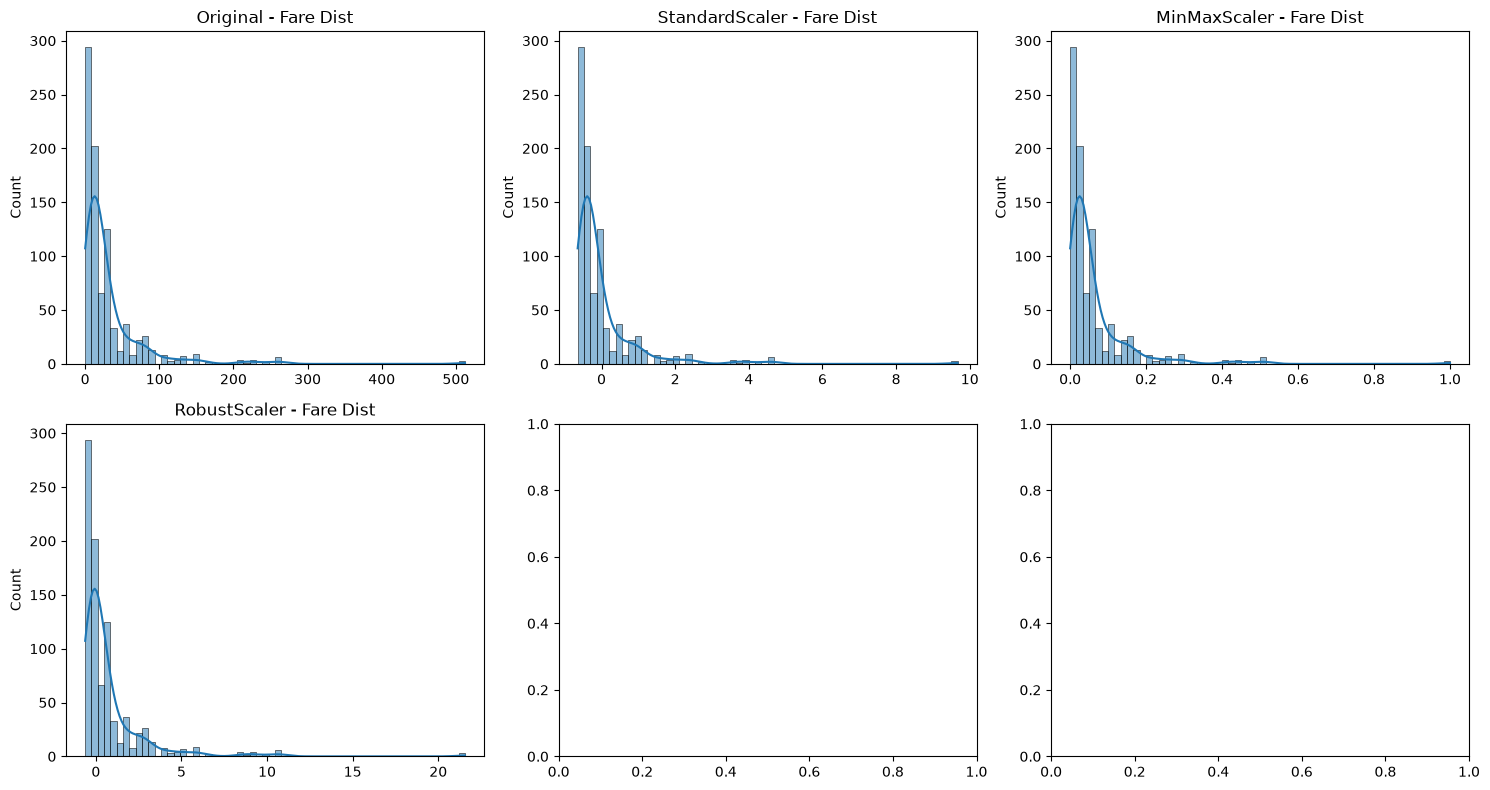

      Feature       Score                                     Why it matters
1  adult_male  400.037563  This combines age and sex, both important surv...
3     who_man  400.037563  Adult men had a survival pattern distinct from...
2    Sex_male  372.405724  Sex was strongly associated with survival duri...
4   who_woman  306.864782  Women had a survival pattern distinct from men...
0      Pclass  115.031272  Passenger class strongly reflects the historic...
Best F-score: 400.04


In [1]:
# --- Setup: 3M Stack Compliant ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the project dataset when available; otherwise use the cached Titanic demo.
project_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'README.md').exists())
data_path = project_root / 'data' / 'train.csv'
df = pd.read_csv(data_path) if data_path.exists() else sns.load_dataset('titanic', data_home=str(project_root / 'data' / 'seaborn'))
df = df.rename(columns={'survived': 'Survived', 'pclass': 'Pclass', 'sex': 'Sex', 'embarked': 'Embarked', 'fare': 'Fare'})

target = 'Survived'
if target not in df.columns:
    raise KeyError(f"Expected target column '{target}', found: {df.columns.tolist()}")
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.drop(target).tolist()

print(f"Categorical: {cat_cols}")
print(f"Numerical: {num_cols}")

# --- TASK 1: Encoding - Trade-offs ---
# Sample data
X_cat = df[cat_cols].fillna('Missing')

# a) LabelEncoder - for TARGET only, not features
le = LabelEncoder()
# Example: df['target_encoded'] = le.fit_transform(df[target])
# Trade-off: Creates false ordinality if used on nominal features. DON'T use on features.

# b) OneHotEncoder - Best for Nominal features with low cardinality
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_encoded = ohe.fit_transform(X_cat[['Embarked']]) # example low-cardinality col
print("OneHot shape:", ohe_encoded.shape)
# Trade-off: PRO - No ordinality assumption. CON - Dimensionality explosion for high-cardinality.

# c) OrdinalEncoder - Best for Ordinal features
# e.g., 'Pclass', 'Education Level' = ['High School', 'Bachelors', 'Masters']
ordinal_cols = ['Pclass'] # example ordered
categories_order = [[1,2,3]] # define order explicitly
oe = OrdinalEncoder(categories=categories_order)
oe_encoded = oe.fit_transform(df[ordinal_cols].dropna())
# Trade-off: PRO - Preserves order, single column. CON - Wrong if order doesn't exist.

# Final recommended Transformer for pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), ['Embarked', 'Sex']),
        ('ordinal', OrdinalEncoder(categories=categories_order), ['Pclass'])
    ], remainder='passthrough')

# --- TASK 2: Scaling - Plot Before/After ---
fig, axes = plt.subplots(2, 3, figsize=(15,8))
scalers = {
    'Original': None,
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

# Use one numeric col with outliers e.g., 'Fare'
col_to_scale = 'Fare'
for i, (name, scaler) in enumerate(scalers.items()):
    if name == 'Original':
        data = df[col_to_scale].dropna()
    else:
        data = scaler.fit_transform(df[[col_to_scale]].dropna())

    ax = axes.flat[i]
    sns.histplot(np.asarray(data).ravel(), kde=True, ax=ax)
    ax.set_title(f"{name} - {col_to_scale} Dist")

    if i>0:
        print(f"{name} -> mean: {data.mean():.2f}, std: {data.std():.2f}, min: {data.min():.2f}, max: {data.max():.2f}")

plt.tight_layout()
output_dir = project_root / 'outputs'
output_dir.mkdir(exist_ok=True)
plt.savefig(output_dir / 'scaling_comparison.png') # Deliverable Evidence
plt.show()

# --- TASK 3: SelectKBest - Top 5 Features ---
# Prepare numeric matrix for selection
X = df[num_cols].fillna(df[num_cols].median())
y = df[target]

# Ensure encoded categoricals are included for fair selection.
# 'alive' is a post-outcome label, so excluding it prevents target leakage.
feature_columns = df.drop(columns=[target, 'alive'], errors='ignore')
X_full = pd.get_dummies(feature_columns, drop_first=True).fillna(0)

selector = SelectKBest(score_func=f_classif, k=5)
selector.fit(X_full, y)

selected_indices = np.flatnonzero(selector.get_support())
top_features = [str(X_full.columns[int(index)]) for index in selected_indices]
scores = np.asarray(selector.scores_, dtype=float)[selected_indices]

feature_reasons = {
    'Fare': 'Ticket price is a proxy for passenger class and access to resources.',
    'Pclass': 'Passenger class strongly reflects the historical survival pattern.',
    'Sex_male': 'Sex was strongly associated with survival during the evacuation.',
    'adult_male': 'This combines age and sex, both important survival factors.',
    'who_man': 'Adult men had a survival pattern distinct from women and children.',
    'who_woman': 'Women had a survival pattern distinct from men and children.',
    'class_Third': 'Third-class travel captures differences in location and access to lifeboats.'
}
feature_importance = pd.DataFrame({
    'Feature': top_features,
    'Score': scores,
    'Why it matters': [feature_reasons.get(feature, 'This feature has a statistically strong association with survival.') for feature in top_features]
}).sort_values('Score', ascending=False)
print(feature_importance)

print(f"Best F-score: {scores.max():.2f}")

# --- CIA Mentor Mode Log (for evaluation) ---
# Prompt 1 to CIA: "Review my ColumnTransformer - am I leaking data by fitting on full df?"
# Prompt 2 to CIA: "Is RobustScaler better than StandardScaler for Fare which has outliers?"